Columns:
 Index(['city_mpg', 'class', 'combination_mpg', 'cylinders', 'displacement',
       'drive', 'fuel_type', 'highway_mpg', 'make', 'model', 'transmission',
       'year'],
      dtype='object')

First 5 rows:
    city_mpg                        class  combination_mpg  cylinders  \
0        25                  midsize car               29        4.0   
1        26                  midsize car               30        4.0   
2        25  small sport utility vehicle               27        4.0   
3        26  small sport utility vehicle               29        4.0   
4        26  small sport utility vehicle               28        4.0   

   displacement drive fuel_type  highway_mpg   make     model transmission  \
0           2.5   fwd       gas           36  mazda         6            m   
1           2.5   fwd       gas           37  mazda         6            a   
2           2.5   fwd       gas           31  mazda  cx-5 2wd            a   
3           2.0   fwd       gas       

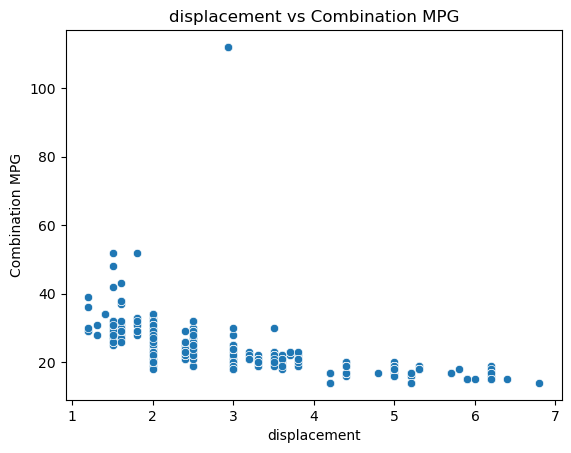

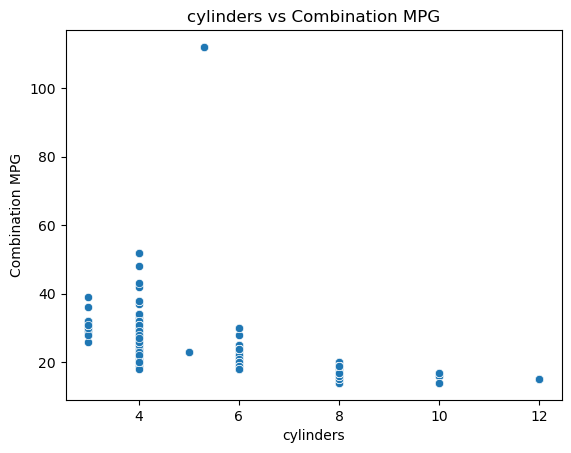

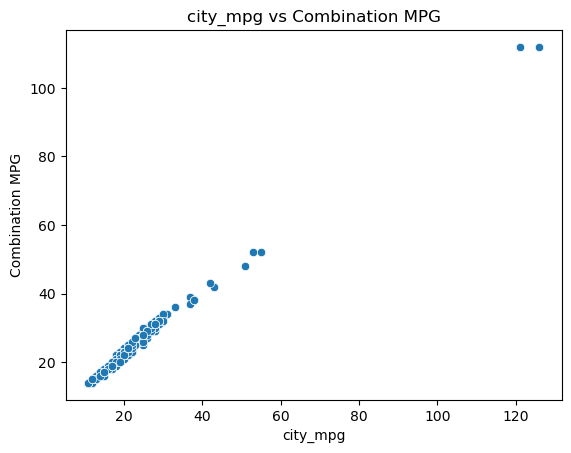

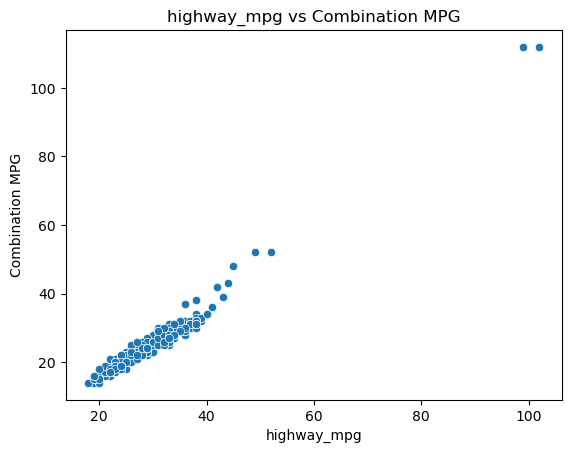


Polynomial Feature Names:
 ['1' 'displacement' 'cylinders' 'city_mpg' 'highway_mpg' 'displacement^2'
 'displacement cylinders' 'displacement city_mpg'
 'displacement highway_mpg' 'cylinders^2' 'cylinders city_mpg'
 'cylinders highway_mpg' 'city_mpg^2' 'city_mpg highway_mpg'
 'highway_mpg^2']

Model Evaluation:
MSE: 0.15414610050337574
R² Score: 0.9940855166348798


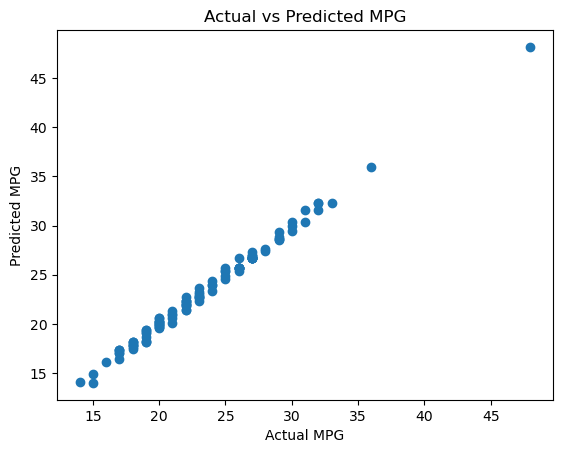

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("car_data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns:\n", df.columns)


print("\nFirst 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

# Fill missing values (numeric only)
df.fillna(df.mean(numeric_only=True), inplace=True)


features = ["displacement", "cylinders", "city_mpg", "highway_mpg"]
X = df[features]

# Target variable
y = df["combination_mpg"]


for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=y)
    plt.title(f"{col} vs Combination MPG")
    plt.xlabel(col)
    plt.ylabel("Combination MPG")
    plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("\nPolynomial Feature Names:\n", poly.get_feature_names_out())


model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MSE:", mse)
print("R² Score:", r2)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()